In [1]:
import sys
sys.path.append('../data_extraction')

import matplotlib.pyplot as plt

from LRO_data_class import LunarDataset

/Users/none/miniconda3/envs/lunar_lro/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = LunarDataset()

dataLabels = ds.labels
dataDEM = ds.DEMLunarData
dataTile = ds.regionalLunarData


Tile: E300N1350 (second tile 2x1)
- **Longitude:** 90°E → 180°E  
- **Latitude:** 0° → 60°N

In [3]:
# Robbins Labbels
smallLabelCraters = dataLabels[
    (dataLabels['DIAM_CIRC_IMG'] < 10) &
    (dataLabels['LAT_CIRC_IMG'] >= 0) &
    (dataLabels['LAT_CIRC_IMG'] <= 60) &
    (dataLabels['LON_CIRC_IMG'] >= 90) &
    (dataLabels['LON_CIRC_IMG'] <= 180) &
    (dataLabels['ARC_IMG'] > 0.5)
]

# DEM
column90 = 90 * 128
column180 = 180 * 128

row60 = (60 - 60) * 128
row0 = (60 - 0) * 128

demTile = dataDEM.values[row60:row0, column90:column180]
smallLabelCraters.to_csv('../data_preparation/filtered_labels.csv', index=False)

print(f'demTile:           {demTile.shape}')
print(f'dataTile:          {dataTile.shape}')
print(f'smallLabelCraters: {smallLabelCraters.shape}')

demTile:           (7680, 11520)
dataTile:          (18194, 27291)
smallLabelCraters: (172774, 21)


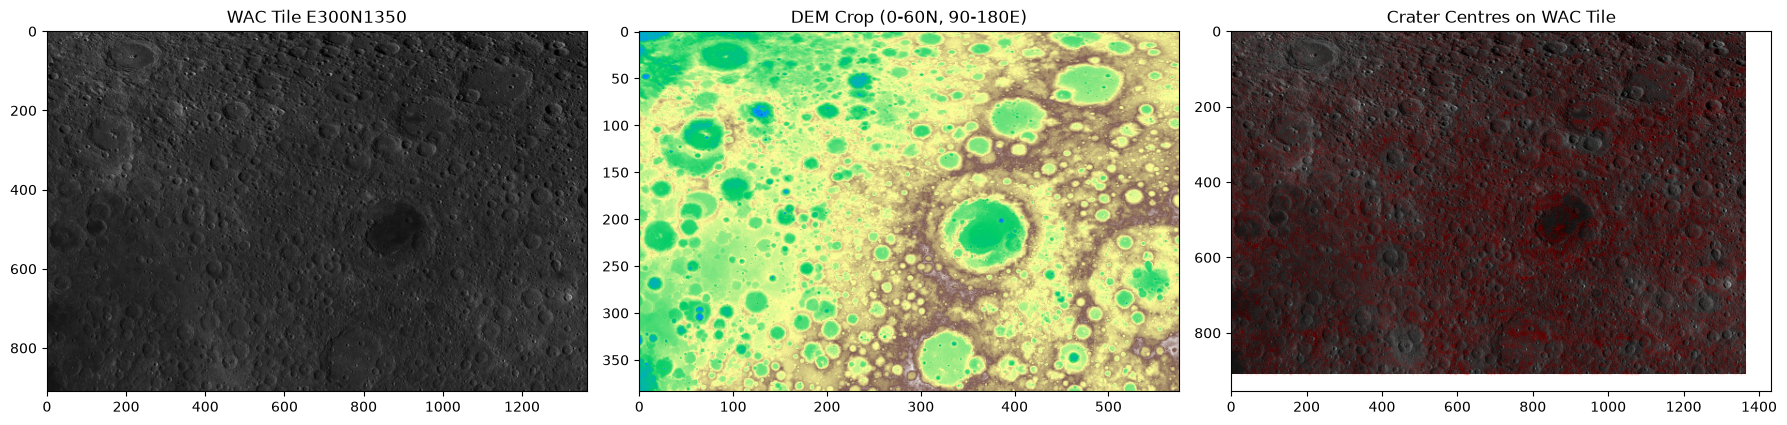

In [4]:
crater_col = (smallLabelCraters['LON_CIRC_IMG'] - 90) * (dataTile.shape[1] / 90) / 20
crater_row = (60 - smallLabelCraters['LAT_CIRC_IMG']) * (dataTile.shape[0] / 60) / 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# WAC tile
axes[0].imshow(dataTile.values[::20, ::20], cmap='gray')
axes[0].set_title('WAC Tile E300N1350')

# DEM crop
axes[1].imshow(demTile[::20, ::20], cmap='terrain')
axes[1].set_title('DEM Crop (0-60N, 90-180E)')

axes[2].imshow(dataTile.values[::20, ::20], cmap='gray')
axes[2].scatter(crater_col, crater_row, s=0.5, c='red', alpha=0.02)
axes[2].set_title('Crater Centres on WAC Tile')

plt.tight_layout()
plt.show()